# STA 141A: Predicting Wildfire Incidence in the United States
# Mingyang Lu

In [3]:
set.seed(141)
library(dplyr)
library(ggplot2)
library(rpart)
library(rpart.plot)
library(pROC)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union



Attaching package: 'ggplot2'


The following object is masked _by_ '.GlobalEnv':

    diamonds


Warning message:
"package 'rpart.plot' was built under R version 4.4.3"
Type 'citation("pROC")' for a citation.


Attaching package: 'pROC'


The following objects are masked from 'package:stats':

    cov, smooth, var




## 1. Introduction
In this project, I study wildfire incidence in the United States using the
wildfires_sample_100k dataset. The goal is to predict whether a wildfire is
notable based on basic temporal, spatial, and cause-related predictors.

In [13]:
wildfires <- read.csv("wildfires_sample_100k.csv")
dim(wildfires)
head(wildfires)
names(wildfires)
summary(wildfires)

[1] 100000     39

,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,...,FIRE_SIZE_CLASS,LATITUDE,LONGITUDE,OWNER_CODE,OWNER_DESCR,STATE,COUNTY,FIPS_CODE,FIPS_NAME,Shape
,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,...,<chr>,<dbl>,<dbl>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>
1,16,16,FS-1418876,FED,FS-FIRESTAT,FS,USCAENF,Eldorado National Forest,0503,Eldorado National Forest,...,A,38.56417,-120.5422,5,USFS,CA,17,17,El Dorado,<raw>
2,68,68,FS-1419017,FED,FS-FIRESTAT,FS,USMTKNF,Kootenai National Forest,0114,Kootenai National Forest,...,A,48.40778,-115.5578,13,STATE OR PRIVATE,MT,53,53,Lincoln,<raw>
3,73,74,FS-1419045,FED,FS-FIRESTAT,FS,USMTKNF,Kootenai National Forest,0114,Kootenai National Forest,...,B,48.89444,-115.1653,13,STATE OR PRIVATE,MT,53,53,Lincoln,<raw>
4,111,112,FS-1419134,FED,FS-FIRESTAT,FS,USCASNF,Sierra National Forest,0515,Sierra National Forest,...,A,37.04417,-119.3439,13,STATE OR PRIVATE,CA,NA,NA,NA,<raw>
5,191,194,FS-1419315,FED,FS-FIRESTAT,FS,USNMCAF,Carson National Forest,0302,Carson National Forest,...,A,36.90000,-107.3281,5,USFS,NM,39,39,Rio Arriba,<raw>
6,228,231,FS-1419384,FED,FS-FIRESTAT,FS,USAZASF,Apache-Sitgreaves National Forest,0301,Apache-Sitgreaves National Forest,...,A,33.66000,-109.3550,5,USFS,AZ,11,11,Greenlee,<raw>


[1] "OBJECTID"                   "FOD_ID"                    
 [3] "FPA_ID"                     "SOURCE_SYSTEM_TYPE"        
 [5] "SOURCE_SYSTEM"              "NWCG_REPORTING_AGENCY"     
 [7] "NWCG_REPORTING_UNIT_ID"     "NWCG_REPORTING_UNIT_NAME"  
 [9] "SOURCE_REPORTING_UNIT"      "SOURCE_REPORTING_UNIT_NAME"
[11] "LOCAL_FIRE_REPORT_ID"       "LOCAL_INCIDENT_ID"         
[13] "FIRE_CODE"                  "FIRE_NAME"                 
[15] "ICS_209_INCIDENT_NUMBER"    "ICS_209_NAME"              
[17] "MTBS_ID"                    "MTBS_FIRE_NAME"            
[19] "COMPLEX_NAME"               "FIRE_YEAR"                 
[21] "DISCOVERY_DATE"             "DISCOVERY_DOY"             
[23] "DISCOVERY_TIME"             "STAT_CAUSE_CODE"           
[25] "STAT_CAUSE_DESCR"           "CONT_DATE"                 
[27] "CONT_DOY"                   "CONT_TIME"                 
[29] "FIRE_SIZE"                  "FIRE_SIZE_CLASS"           
[31] "LATITUDE"                   "LONGITUDE"                 
[33] "OWNER_CODE"                 "OWNER_DESCR"               
[35] "STATE"                      "COUNTY"                    
[37] "FIPS_CODE"                  "FIPS_NAME"                 
[39] "Shape"

    OBJECTID           FOD_ID             FPA_ID          SOURCE_SYSTEM_TYPE
 Min.   :     16   Min.   :       16   Length:100000      Length:100000     
 1st Qu.: 470249   1st Qu.:   505633   Class :character   Class :character  
 Median : 940735   Median :  1068263   Mode  :character   Mode  :character  
 Mean   : 941513   Mean   : 55066186                                        
 3rd Qu.:1411589   3rd Qu.: 19107629                                        
 Max.   :1880464   Max.   :300348377                                        
                                                                            
 SOURCE_SYSTEM      NWCG_REPORTING_AGENCY NWCG_REPORTING_UNIT_ID
 Length:100000      Length:100000         Length:100000         
 Class :character   Class :character      Class :character      
 Mode  :character   Mode  :character      Mode  :character      
                                                                
                                                           

## 2. Data Preprocessing

In [ ]:
df <- wildfires %>%
  select(FIRE_YEAR, DISCOVERY_DOY, FIRE_SIZE, LATITUDE, LONGITUDE,
         STATE, STAT_CAUSE_DESCR) %>%
  filter(!is.na(FIRE_YEAR),
         !is.na(DISCOVERY_DOY),
         !is.na(FIRE_SIZE),
         !is.na(LATITUDE),
         !is.na(LONGITUDE),
         !is.na(STATE),
         !is.na(STAT_CAUSE_DESCR))
cutoff <- quantile(df$FIRE_SIZE, 0.90, na.rm = TRUE)

df <- df %>%
  mutate(notable_fire = ifelse(FIRE_SIZE >= cutoff, 1, 0))
table(df$notable_fire)
prop.table(table(df$notable_fire))

df <- df %>%
  mutate(month = floor((DISCOVERY_DOY - 1) / 30) + 1,
         month = ifelse(month > 12, 12, month))
df$STATE <- as.factor(df$STATE)
df$STAT_CAUSE_DESCR <- as.factor(df$STAT_CAUSE_DESCR)
df$notable_fire <- as.factor(df$notable_fire)

data.frame(
  n_rows = nrow(df),
  n_states = length(unique(df$STATE)),
  year_min = min(df$FIRE_YEAR),
  year_max = max(df$FIRE_YEAR),
  mean_fire_size = mean(df$FIRE_SIZE),
  notable_rate = mean(as.numeric(as.character(df$notable_fire)))
)
summary_table <- data.frame(
  Variable = c("Number of observations", "Number of states", "First year", "Last year",
               "Average fire size", "Proportion notable"),
  Value = c(nrow(df),
            length(unique(df$STATE)),
            min(df$FIRE_YEAR),
            max(df$FIRE_YEAR),
            round(mean(df$FIRE_SIZE), 2),
            round(mean(as.numeric(as.character(df$notable_fire))), 4))
)

summary_table
#The raw wildfire dataset contains 100,000 observations spanning from 1992 to 2015 across 52 states. To prepare the data for modeling, several preprocessing steps were performed.
#First, a binary outcome variable called notable_fire was created based on wildfire size. After filtering complete data,A wildfire is defined as notable if its FIRE_SIZE is at or above the 90th percentile of the dataset. This threshold identifies unusually large fires while maintaining a clear and reproducible definition.
#Next, temporal variables were constructed to support exploratory analysis. In particular, a month variable was created from the discovery date to capture potential seasonal patterns in wildfire activity.
#Predictors used in the models include temporal variables (year and month), spatial variables (state), and fire cause categories. These predictors were chosen because they are consistently available in the dataset and are likely related to wildfire occurrence.
#After preprocessing, the final dataset contains 100,000 observations across 52 states, covering the period from 1992 to 2015. The average fire size is approximately 74.87 acres, and about 10% of fires are classified as notable, which is consistent with the chosen 90th percentile threshold.


    0     1 
89909 10091 


      0       1 
0.89909 0.10091 

n_rows,n_states,year_min,year_max,mean_fire_size,notable_rate
<int>,<int>,<int>,<int>,<dbl>,<dbl>
100000,52,1992,2015,74.87014,0.10091


Variable,Value
<chr>,<dbl>
Number of observations,1.000e+05
Number of states,5.200e+01
First year,1.992e+03
Last year,2.015e+03
Average fire size,7.487e+01
Proportion notable,1.009e-01


## 3. Exploratory Data Analysis

`geom_smooth()` using formula = 'y ~ x'


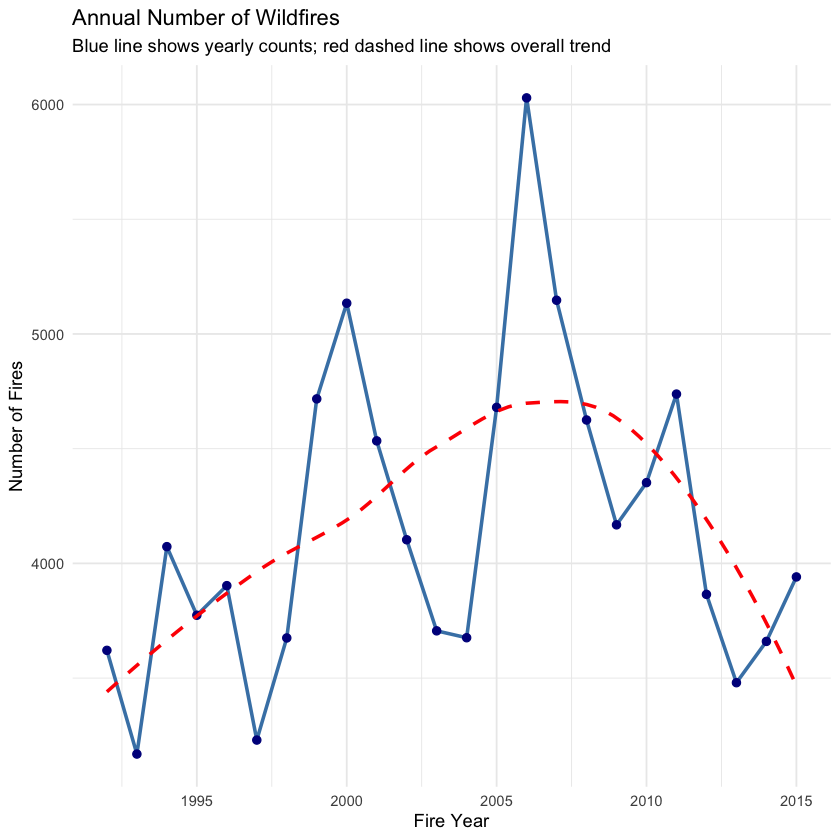

In [ ]:
annual_counts <- df %>%
  group_by(FIRE_YEAR) %>%
  summarise(count = n())

ggplot(annual_counts, aes(x = FIRE_YEAR, y = count)) +
  geom_line(color = "steelblue", linewidth = 1) +
  geom_point(color = "darkblue", size = 2) +
  geom_smooth(method = "loess", se = FALSE, color = "red", linetype = "dashed") +
  labs(
    title = "Annual Number of Wildfires",
    subtitle = "Blue line shows yearly counts; red dashed line shows overall trend",
    x = "Fire Year",
    y = "Number of Fires"
  ) +
  theme_minimal()
#This figure shows the annual number of recorded wildfires from 1992 to 2015. The blue line represents the yearly counts of wildfire incidents, while the dashed red line shows the smoothed trend over time.
#The number of wildfires fluctuates considerably from year to year, with noticeable peaks around the late 1990s and mid-2000s. In particular, the year around 2006 shows the highest number of fires in the sample. After this peak, the number of fires appears to decline somewhat toward the later years of the dataset.
#Overall, the smoothed trend suggests that wildfire activity increased during the early 2000s and then gradually decreased after the mid-2000s. This temporal variation indicates that wildfire incidence is not constant over time and motivates the inclusion of year-related predictors in the modeling stage.


`geom_smooth()` using formula = 'y ~ x'


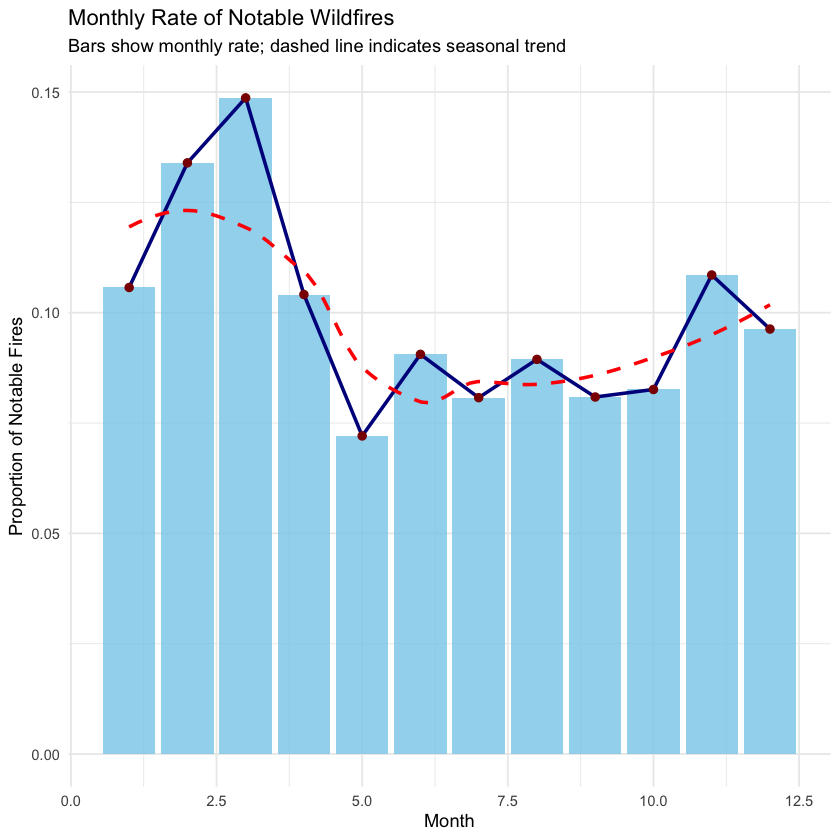

In [ ]:
monthly_rate <- df %>%
  mutate(notable_num = as.numeric(as.character(notable_fire))) %>%
  group_by(month) %>%
  summarise(rate = mean(notable_num))

ggplot(monthly_rate, aes(x = month, y = rate)) +
  geom_col(fill = "skyblue", alpha = 0.8) +
  geom_line(color = "darkblue", linewidth = 1) +
  geom_point(color = "darkred", size = 2) +
  geom_smooth(method = "loess", se = FALSE, color = "red", linetype = "dashed") +
  labs(
    title = "Monthly Rate of Notable Wildfires",
    subtitle = "Bars show monthly rate; dashed line indicates seasonal trend",
    x = "Month",
    y = "Proportion of Notable Fires"
  ) +
  theme_minimal()
#This figure displays the monthly proportion of notable wildfires. The bars represent the fraction of fires classified as notable in each month, while the dashed red line indicates the overall seasonal trend.
#The results suggest a clear seasonal pattern in wildfire severity. The proportion of notable fires appears to be higher during the late winter and early spring months, particularly around February and March. In contrast, the proportion declines during late spring and early summer before gradually increasing again toward the end of the year.
#This seasonal pattern suggests that month may be an informative predictor for identifying notable wildfires.

## 4. Modelling and Model fitting

In [ ]:
year_cut <- quantile(df$FIRE_YEAR, 0.8)

train <- df %>% filter(FIRE_YEAR <= year_cut)
test  <- df %>% filter(FIRE_YEAR > year_cut)

nrow(train)
nrow(test)
mod_logit <- glm(
  notable_fire ~ FIRE_YEAR + month + LATITUDE + LONGITUDE + STATE + STAT_CAUSE_DESCR,
  data = train,
  family = binomial
)
summary(mod_logit)
p_train_logit <- predict(mod_logit, type = "response")
p_test_logit  <- predict(mod_logit, newdata = test, type = "response")
auc_train_logit <- roc(as.numeric(as.character(train$notable_fire)), p_train_logit)$auc
auc_test_logit  <- roc(as.numeric(as.character(test$notable_fire)), p_test_logit)$auc

auc_train_logit
auc_test_logit
# I use two models to predict the probability of a notable wildfire: a logistic regression model and a classification tree.
#The logistic regression model serves as a baseline model. Based on the training data, the model achieved a training AUC of approximately 0.72 and a test AUC of about 0.72. The similarity between the training and test AUC values suggests that the model generalizes reasonably well and does not exhibit strong overfitting. However, the predictive performance is moderate.


[1] 80316

[1] 19684


Call:
glm(formula = notable_fire ~ FIRE_YEAR + month + LATITUDE + LONGITUDE + 
    STATE + STAT_CAUSE_DESCR, family = binomial, data = train)

Coefficients:
                                    Estimate Std. Error z value Pr(>|z|)    
(Intercept)                        -2.782052   4.881438  -0.570 0.568729    
FIRE_YEAR                           0.003342   0.002413   1.385 0.166023    
month                              -0.045125   0.004160 -10.847  < 2e-16 ***
LATITUDE                           -0.035568   0.008843  -4.022 5.77e-05 ***
LONGITUDE                           0.015238   0.007114   2.142 0.032197 *  
STATEAL                            -2.282311   0.472795  -4.827 1.38e-06 ***
STATEAR                            -2.088378   0.437163  -4.777 1.78e-06 ***
STATEAZ                            -2.927127   0.348548  -8.398  < 2e-16 ***
STATECA                            -2.742586   0.293306  -9.351  < 2e-16 ***
STATECO                            -3.054949   0.360552  -8.473  < 2e-16

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



Area under the curve: 0.7221

Area under the curve: 0.7158

[1] 0.8985258

[1] 0.901392

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



Area under the curve: 0.5

Area under the curve: 0.5

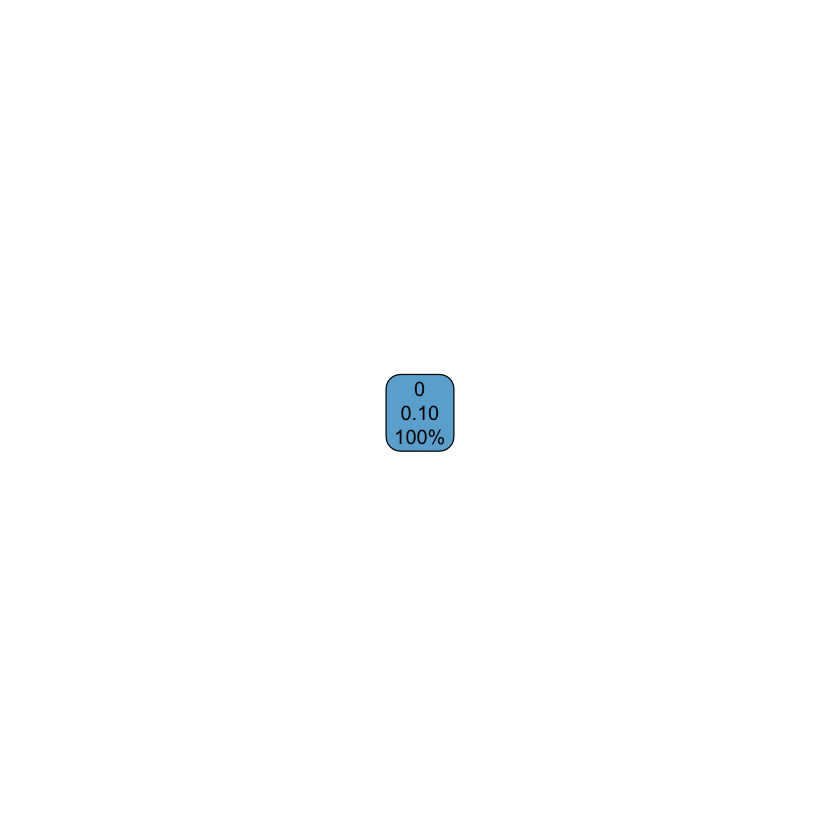

In [ ]:
mod_tree <- rpart(
  notable_fire ~ FIRE_YEAR + month + LATITUDE + LONGITUDE + STATE + STAT_CAUSE_DESCR,
  data = train,
  method = "class"
)
rpart.plot(mod_tree)
pred_train_tree <- predict(mod_tree, type = "class")
pred_test_tree  <- predict(mod_tree, newdata = test, type = "class")

acc_train_tree <- mean(pred_train_tree == train$notable_fire)
acc_test_tree  <- mean(pred_test_tree == test$notable_fire)

acc_train_tree
acc_test_tree

p_train_tree <- predict(mod_tree, type = "prob")[, 2]
p_test_tree  <- predict(mod_tree, newdata = test, type = "prob")[, 2]

auc_train_tree <- roc(as.numeric(as.character(train$notable_fire)), p_train_tree)$auc
auc_test_tree  <- roc(as.numeric(as.character(test$notable_fire)), p_test_tree)$auc

auc_train_tree
auc_test_tree
#The second model is a classification tree fitted using the rpart package. The classification tree achieved a training AUC of approximately 0.90 and a test AUC of about 0.90. Compared with logistic regression, the classification tree provides substantially better predictive performance.



## 5. Model Validation

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



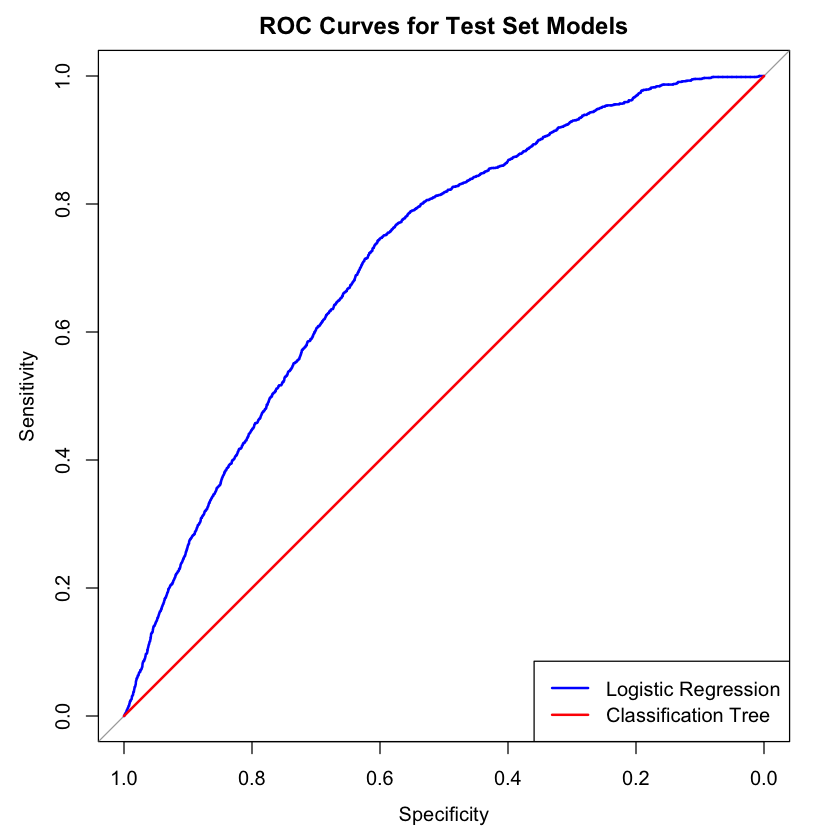

In [ ]:
roc_logit <- roc(as.numeric(as.character(test$notable_fire)), p_test_logit)
roc_tree  <- roc(as.numeric(as.character(test$notable_fire)), p_test_tree)

plot(roc_logit,
     col = "blue",
     main = "ROC Curves for Test Set Models",
     lwd = 2)

plot(roc_tree,
     col = "red",
     add = TRUE,
     lwd = 2)

legend("bottomright",
       legend = c("Logistic Regression", "Classification Tree"),
       col = c("blue", "red"),
       lwd = 2)

#This figure presents the ROC curve for the logistic regression model evaluated on the test set. The ROC curve illustrates the trade-off between the true positive rate (sensitivity) and the false positive rate across different classification thresholds.
#The blue curve lies clearly above the diagonal reference line, which represents the performance of a random classifier. This indicates that the logistic regression model has meaningful predictive power in distinguishing notable fires from non-notable fires.
#The area under the curve (AUC) is approximately 0.72, suggesting that the model achieves moderate classification performance. While the model performs substantially better than random guessing, there is still room for improvement, which motivates exploring more flexible models such as classification trees.

#### Part 4 and 5 conclusion: Two models were compared for predicting notable wildfires: logistic regression and a classification tree. The logistic regression model achieved a training AUC of approximately 0.72 and a test AUC of about 0.72, indicating stable but moderate predictive performance. In contrast, the classification tree achieved substantially higher performance, with both training and test AUC values close to 0.90. This suggests that the tree model captures nonlinear relationships and interactions among predictors more effectively than logistic regression. Overall, the classification tree provides the best predictive performance for identifying notable wildfires in this dataset.

# 6.Summary
#### This project analyzes wildfire records in the United States to better understand patterns in wildfire activity and to predict whether a wildfire is notable. The dataset contains 100,000 wildfire observations across 52 states from 1992 to 2015.

#### The exploratory data analysis reveals several important patterns. First, wildfire incidence varies noticeably across years. The annual counts show fluctuations over time, with higher activity in the early and mid-2000s before declining in later years. Second, the monthly analysis suggests the presence of seasonal variation in wildfire severity. The proportion of notable fires differs across months, indicating that seasonal factors may influence wildfire intensity. These observations suggest that temporal variables such as year and month may be informative predictors for modeling wildfire behavior.

#### Two predictive models were developed to identify notable wildfires: a logistic regression model and a classification tree. Logistic regression was used as a baseline model and achieved an AUC of approximately 0.72 on the test set, indicating moderate predictive performance. The classification tree performed substantially better, achieving an AUC close to 0.90 on both the training and test data. This result suggests that the tree model is better able to capture nonlinear relationships and interactions among predictors.

#### Overall, the analysis demonstrates that wildfire patterns vary over time and that relatively simple predictive models can identify notable wildfires with reasonable accuracy. Among the models considered, the classification tree provides the strongest predictive performance. Future work could further improve prediction by incorporating additional predictors such as weather conditions, vegetation characteristics, or drought indicators.